# Hierarchical Clustering — A Visual, Beginner-Friendly Guide

Hierarchical clustering finds groups by repeatedly joining the closest observations. Its most useful picture is a **dendrogram**: a tree that shows what joined, and when it joined.

> **Simple idea:** start with every point in its own group, then keep joining nearby groups until only one large group remains.

## What you will learn

By the end of this notebook, you will be able to:

- explain hierarchical clustering in plain language,
- read a dendrogram,
- choose a reasonable number of clusters visually, and
- build and display the final clusters with Python.

We will use only nine points so every step is easy to see.

## The story: nine strangers in an empty town

Nine people move into an empty town on the same day.

Nobody knows anybody. Every person stands alone. So on day one there are **nine groups, with one person in each**.

Then one simple rule starts running, again and again:

> **The two closest groups shake hands and become one group.**

That is the whole algorithm. Repeat that rule until only one big group is left.

Everything else in this notebook is detail about that one rule:

| In the story | In machine learning |
|---|---|
| One person | One data point |
| "Who is nearest to me?" | Distance |
| "How do two *groups* measure closeness?" | Linkage |
| The diary of every handshake | Dendrogram |
| Stopping the story early | Cutting the tree |

We build upward, starting from single points. That is why this is called **agglomerative** (bottom-up) hierarchical clustering.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import AgglomerativeClustering

# A clean and consistent style for every chart in this lesson
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (9, 5.5), "font.size": 11})

# Each row is one observation with two features.
points = np.array([
    [5, 3], [10, 15], [15, 12], [24, 10], [30, 30],
    [85, 70], [71, 80], [60, 78], [70, 55]
])
point_names = [f"P{i}" for i in range(1, len(points) + 1)]

print(f"Dataset shape: {points.shape[0]} points and {points.shape[1]} features")

Dataset shape: 9 points and 2 features


## 1. First, look at the data

The two columns are called **Feature 1** and **Feature 2**. They could represent real measurements such as income and spending, height and weight, or any other pair of numeric features.

Before using an algorithm, always plot the data. Ask: **Do some points appear naturally close together?**

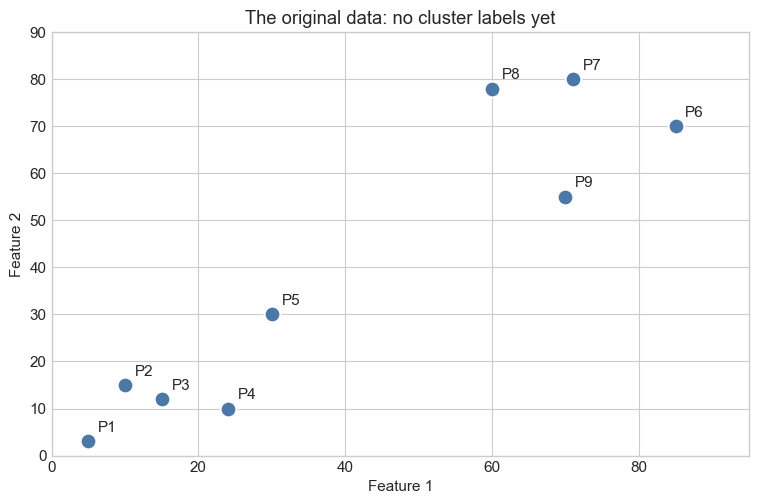

In [2]:
fig, ax = plt.subplots()
ax.scatter(
    points[:, 0], points[:, 1],
    s=130, color="#4C78A8", edgecolor="white", linewidth=1.5
)

for name, (x, y) in zip(point_names, points):
    ax.annotate(name, (x, y), xytext=(7, 7), textcoords="offset points")

ax.set(
    title="The original data: no cluster labels yet",
    xlabel="Feature 1",
    ylabel="Feature 2"
)
ax.set_xlim(0, 95)
ax.set_ylim(0, 90)
plt.show()

### What can we already see?

The points on the lower-left look far away from the points on the upper-right. Our eyes suggest two broad groups, but the algorithm has not received any group labels. This is why clustering is called **unsupervised learning**.

### Story step 1 — "Who is nearest to me?"

Before anybody can shake hands, each person must know who is closest.

We measure that with plain straight-line distance. Walk across, then walk up, then use the triangle rule.

The chart below points out each part of that triangle.

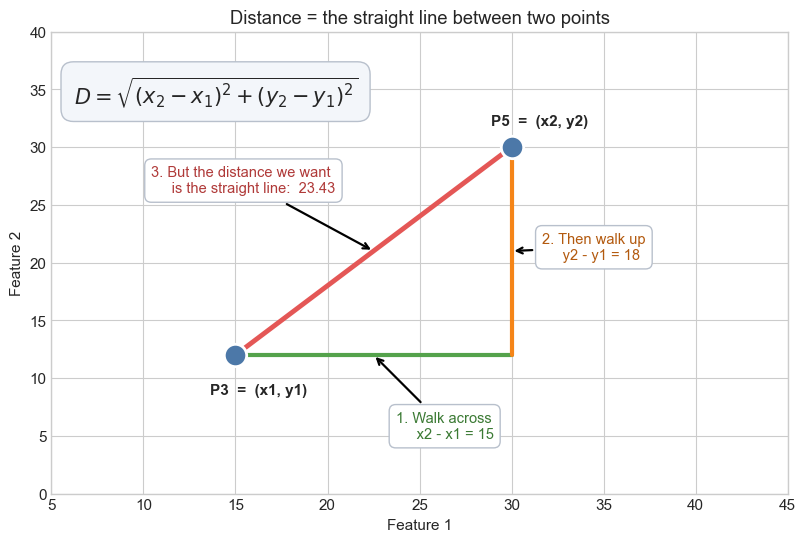

Walk across : 15
Walk up     : 18
Distance D  : 23.43


In [3]:
# "Who is near me?" -> measure it with a right-angle triangle.
p1, p2 = points[2], points[4]          # P3 and P5
walk_across = p2[0] - p1[0]
walk_up = p2[1] - p1[1]
straight_line = np.hypot(walk_across, walk_up)

fig, ax = plt.subplots(figsize=(9.5, 6))

# The two sides you can walk, and the straight line you actually want.
ax.plot([p1[0], p2[0]], [p1[1], p1[1]], color="#54A24B", linewidth=3)
ax.plot([p2[0], p2[0]], [p1[1], p2[1]], color="#F58518", linewidth=3)
ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="#E45756", linewidth=3.5, zorder=4)

ax.scatter(*p1, s=260, color="#4C78A8", edgecolor="white", linewidth=2, zorder=5)
ax.scatter(*p2, s=260, color="#4C78A8", edgecolor="white", linewidth=2, zorder=5)
ax.annotate("P3  =  (x1, y1)", p1, xytext=(-18, -28), textcoords="offset points", fontweight="bold")
ax.annotate("P5  =  (x2, y2)", p2, xytext=(-15, 16), textcoords="offset points", fontweight="bold")

label = dict(arrowprops=dict(arrowstyle="->", linewidth=1.6), fontsize=10.5,
             bbox=dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor="#B8C0CC"))

ax.annotate(f"1. Walk across\n     x2 - x1 = {walk_across}",
            xy=((p1[0] + p2[0]) / 2, p1[1]), xytext=(16, -60), textcoords="offset points",
            color="#3B7A34", **label)
ax.annotate(f"2. Then walk up\n     y2 - y1 = {walk_up}",
            xy=(p2[0], (p1[1] + p2[1]) / 2), xytext=(22, -6), textcoords="offset points",
            color="#B35A0F", **label)
ax.annotate(f"3. But the distance we want\n     is the straight line:  {straight_line:.2f}",
            xy=((p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2), xytext=(-160, 42),
            textcoords="offset points", color="#B03A39", **label)

ax.text(0.03, 0.87, r"$D=\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}$", transform=ax.transAxes,
        ha="left", va="center", fontsize=15,
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#F3F6FA", edgecolor="#B8C0CC"))

ax.set(title="Distance = the straight line between two points",
       xlabel="Feature 1", ylabel="Feature 2")
ax.set_xlim(5, 45); ax.set_ylim(0, 40)
plt.show()

print(f"Walk across : {walk_across}")
print(f"Walk up     : {walk_up}")
print(f"Distance D  : {straight_line:.2f}")

## 2. How agglomerative clustering works

**Agglomerative** means “building upward by joining.” The algorithm follows four repeated steps:

1. Treat every point as its own cluster.
2. Find the two closest clusters.
3. Join them into one larger cluster.
4. Repeat until everything belongs to one cluster.

The next chart highlights the first pair the algorithm can join.

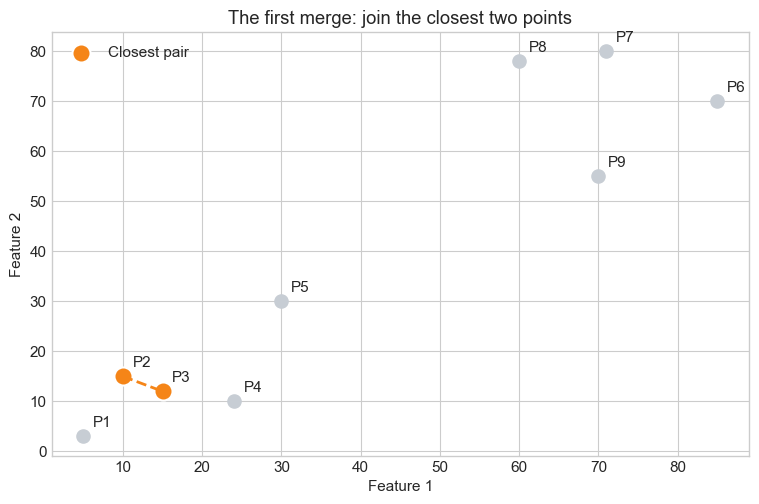

Closest pair: P2 and P3 (distance = 5.83)


In [4]:
# Calculate the straight-line (Euclidean) distance between every pair.
distance_matrix = squareform(pdist(points, metric="euclidean"))
np.fill_diagonal(distance_matrix, np.inf)  # A point should not match with itself.
first_i, first_j = np.unravel_index(np.argmin(distance_matrix), distance_matrix.shape)
closest_distance = distance_matrix[first_i, first_j]

fig, ax = plt.subplots()
ax.scatter(points[:, 0], points[:, 1], s=90, color="#C7CDD4")
ax.scatter(
    points[[first_i, first_j], 0], points[[first_i, first_j], 1],
    s=170, color="#F58518", edgecolor="white", linewidth=1.5,
    label="Closest pair"
)
ax.plot(
    points[[first_i, first_j], 0], points[[first_i, first_j], 1],
    linestyle="--", color="#F58518", linewidth=2
)

for name, (x, y) in zip(point_names, points):
    ax.annotate(name, (x, y), xytext=(7, 7), textcoords="offset points")

ax.set(
    title="The first merge: join the closest two points",
    xlabel="Feature 1", ylabel="Feature 2"
)
ax.legend()
plt.show()

print(
    f"Closest pair: {point_names[first_i]} and {point_names[first_j]} "
    f"(distance = {closest_distance:.2f})"
)

### Story step 2 — the smallest possible story: three people

Take only three people: **A**, **B** and **C**. There are three distances between them: d1, d2 and d3.

- d1 is the smallest, so **A and B shake hands first**.
- Now only two groups are left: `{A, B}` and `{C}`.
- They shake hands too. Everyone is one group, and the story ends.

Below are two pictures of that same story.
The **left** picture is the town map. The **right** picture is the diary, called a **dendrogram**.

Notice that the boxes on the left are nested. A small group sits inside a bigger group. That nesting is the "hierarchy" in hierarchical clustering.

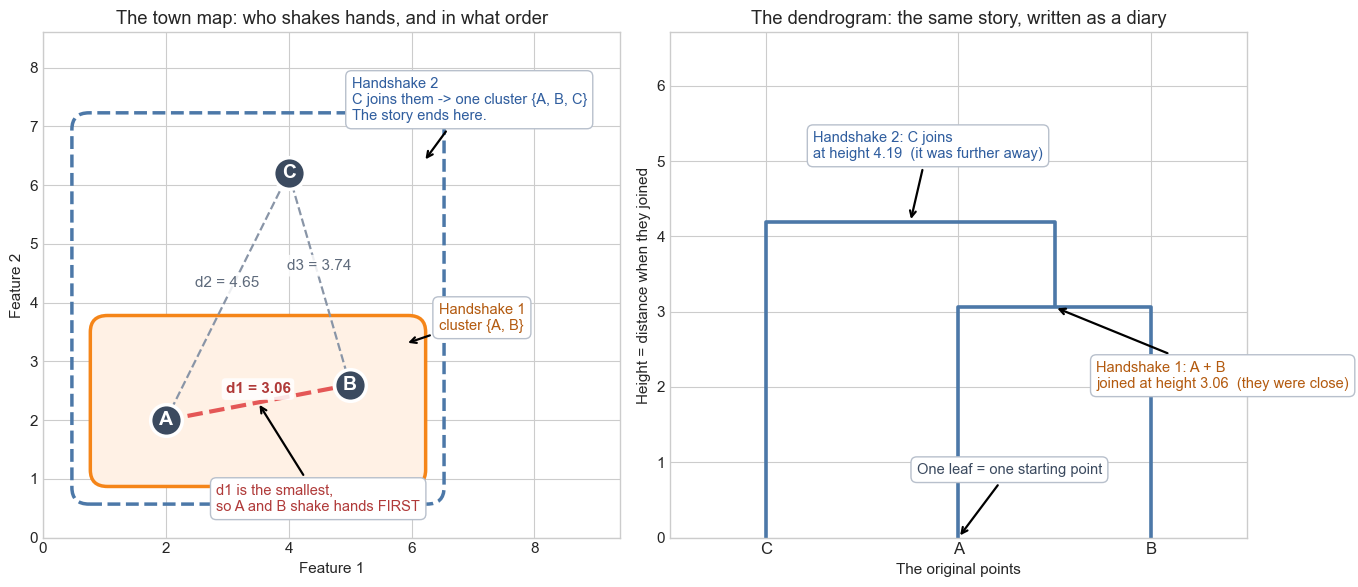

d1  A-B = 3.06   <-- smallest, merged first
d2  A-C = 4.65
d3  B-C = 3.74


In [5]:
from matplotlib.patches import FancyBboxPatch

trio = np.array([[2.0, 2.0], [5.0, 2.6], [4.0, 6.2]])
trio_names = ["A", "B", "C"]
d_ab = np.linalg.norm(trio[0] - trio[1])
d_ac = np.linalg.norm(trio[0] - trio[2])
d_bc = np.linalg.norm(trio[1] - trio[2])

fig, (ax_map, ax_tree) = plt.subplots(1, 2, figsize=(14, 6))

# ---------- LEFT: the town map, with the two handshakes drawn as boxes ----------
ax_map.add_patch(FancyBboxPatch(
    (1.05, 1.15), 4.9, 2.35, boxstyle="round,pad=0.28",
    facecolor="#FFF1E5", edgecolor="#F58518", linewidth=2.5, zorder=1))
ax_map.add_patch(FancyBboxPatch(
    (0.75, 0.85), 5.5, 6.1, boxstyle="round,pad=0.28",
    facecolor="none", edgecolor="#4C78A8", linewidth=2.5, linestyle="--", zorder=1))

for (x, y), name in zip(trio, trio_names):
    ax_map.scatter(x, y, s=520, color="#3B4A5F", edgecolor="white", linewidth=2.5, zorder=6)
    ax_map.text(x, y, name, color="white", fontsize=14, fontweight="bold",
                ha="center", va="center", zorder=7)

for (i, j), dist, name in [((0, 1), d_ab, "d1"), ((0, 2), d_ac, "d2"), ((1, 2), d_bc, "d3")]:
    strongest = name == "d1"
    ax_map.plot(trio[[i, j], 0], trio[[i, j], 1],
                linestyle="--", linewidth=3 if strongest else 1.6,
                color="#E45756" if strongest else "#8995A7", zorder=3)
    mid = trio[[i, j]].mean(axis=0)
    ax_map.text(mid[0], mid[1] + 0.16, f"{name} = {dist:.2f}",
                ha="center", fontsize=11, fontweight="bold" if strongest else "normal",
                color="#B03A39" if strongest else "#5F6B7C",
                bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="none", alpha=.85))

tag = dict(arrowprops=dict(arrowstyle="->", linewidth=1.6), fontsize=10.5,
           bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#B8C0CC"))
ax_map.annotate("d1 is the smallest,\nso A and B shake hands FIRST",
                xy=(3.5, 2.3), xytext=(-30, -78), textcoords="offset points",
                color="#B03A39", **tag)
ax_map.annotate("Handshake 1\ncluster {A, B}",
                xy=(5.9, 3.3), xytext=(24, 10), textcoords="offset points",
                color="#B35A0F", **tag)
ax_map.annotate("Handshake 2\nC joins them -> one cluster {A, B, C}\nThe story ends here.",
                xy=(6.2, 6.4), xytext=(-52, 30), textcoords="offset points",
                color="#2F5D9E", **tag)

ax_map.set(title="The town map: who shakes hands, and in what order",
           xlabel="Feature 1", ylabel="Feature 2")
ax_map.set_xlim(0, 9.4); ax_map.set_ylim(0, 8.6)

# ---------- RIGHT: the same two handshakes, drawn as the diary ----------
trio_link = linkage(trio, method="average", metric="euclidean")
tree = dendrogram(trio_link, labels=trio_names, ax=ax_tree,
                  above_threshold_color="#4C78A8", color_threshold=0)
for coll in ax_tree.collections:
    coll.set_linewidth(2.6)

first_bar = min(zip(tree["dcoord"], tree["icoord"]), key=lambda t: max(t[0]))
last_bar = max(zip(tree["dcoord"], tree["icoord"]), key=lambda t: max(t[0]))

ax_tree.annotate(f"Handshake 1: A + B\njoined at height {max(first_bar[0]):.2f}  (they were close)",
                 xy=(np.mean(first_bar[1][1:3]), max(first_bar[0])),
                 xytext=(30, -58), textcoords="offset points", color="#B35A0F", **tag)
ax_tree.annotate(f"Handshake 2: C joins\nat height {max(last_bar[0]):.2f}  (it was further away)",
                 xy=(np.mean(last_bar[1][1:3]), max(last_bar[0])),
                 xytext=(-70, 46), textcoords="offset points", color="#2F5D9E", **tag)
ax_tree.annotate("One leaf = one starting point",
                 xy=(tree["icoord"][0][0], 0), xytext=(-30, 46), textcoords="offset points",
                 color="#3B4A5F", **tag)

ax_tree.set(title="The dendrogram: the same story, written as a diary",
            xlabel="The original points", ylabel="Height = distance when they joined")
ax_tree.set_ylim(0, max(last_bar[0]) * 1.6)

fig.tight_layout()
plt.show()

print(f"d1  A-B = {d_ab:.2f}   <-- smallest, merged first")
print(f"d2  A-C = {d_ac:.2f}")
print(f"d3  B-C = {d_bc:.2f}")

### Story step 3 — replay all nine handshakes

Nine points need **eight** handshakes to become one group.

Read the panels below in order. In each panel:

- the **red dashed line** is the handshake that just happened,
- each **colour** is a group that exists at that moment,
- the thin lines inside a colour show who already belongs together.

Watch the order. Near points join early and cheaply. The two far-apart halves of the town join last, and that last handshake is very expensive.

> The number in each title is the **join height**. With Ward linkage this is a merge cost, not a plain distance. What matters is the order, and the size of the jumps.

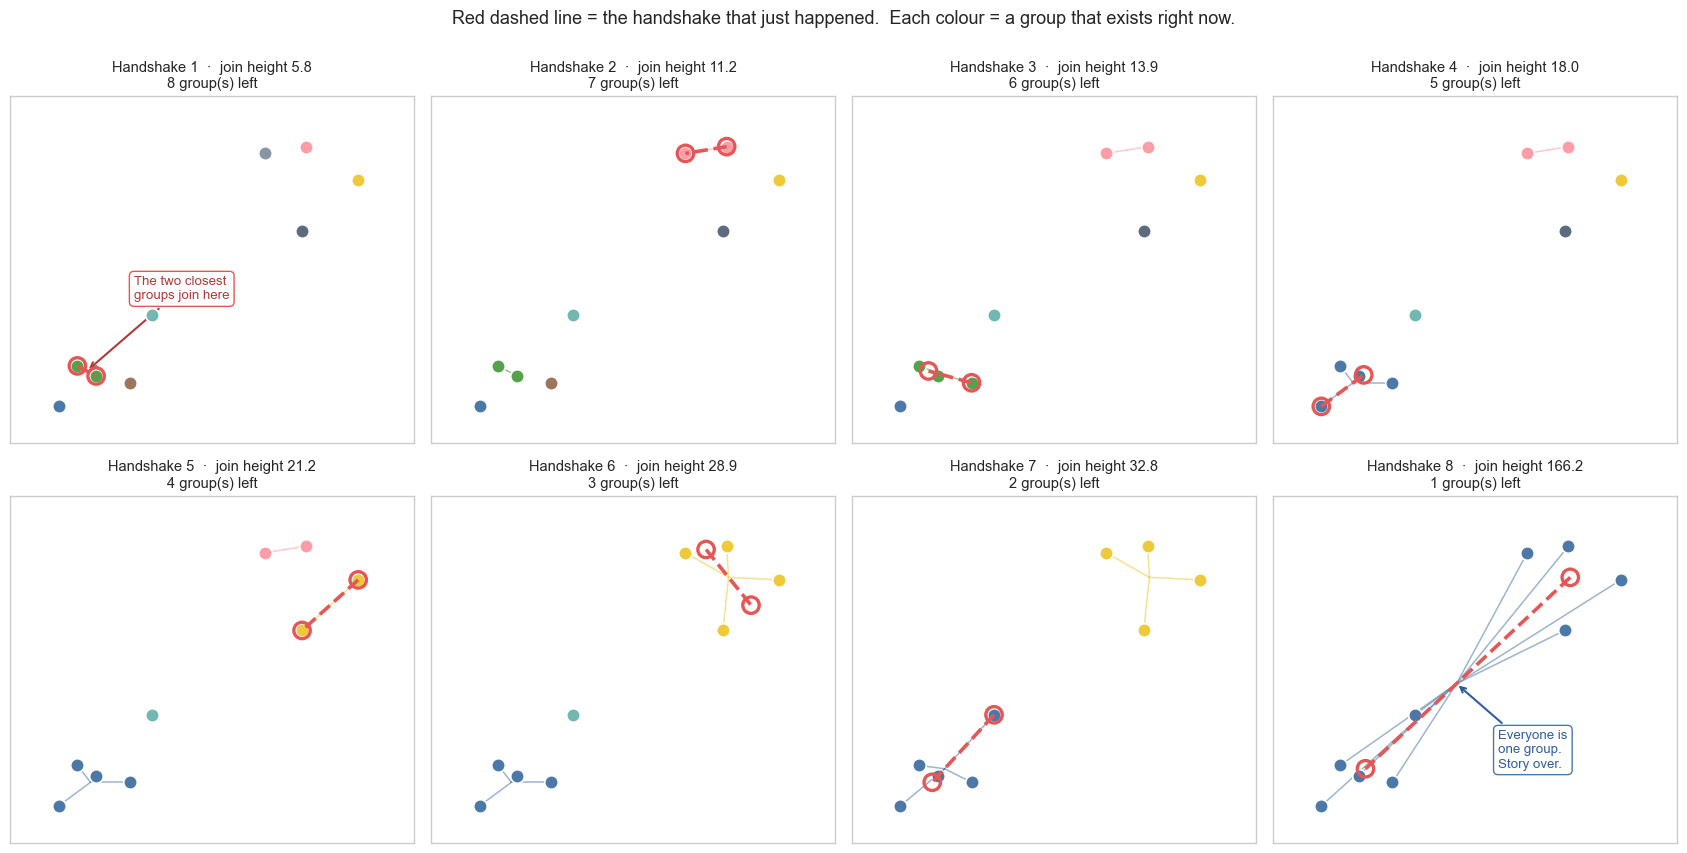

handshake 1: joined ['P2'] + ['P3']  at height 5.83
handshake 2: joined ['P7'] + ['P8']  at height 11.18
handshake 3: joined ['P4'] + ['P2', 'P3']  at height 13.88
handshake 4: joined ['P1'] + ['P4', 'P2', 'P3']  at height 17.98
handshake 5: joined ['P6'] + ['P9']  at height 21.21
handshake 6: joined ['P7', 'P8'] + ['P6', 'P9']  at height 28.85
handshake 7: joined ['P5'] + ['P1', 'P4', 'P2', 'P3']  at height 32.80
handshake 8: joined ['P7', 'P8', 'P6', 'P9'] + ['P5', 'P1', 'P4', 'P2', 'P3']  at height 166.17


In [6]:
# Replay the story one handshake at a time.
Z = linkage(points, method="ward", metric="euclidean")
n = len(points)

groups = {i: [i] for i in range(n)}
history = []
for step, row in enumerate(Z, start=1):
    a, b, dist = int(row[0]), int(row[1]), row[2]
    left, right = groups.pop(a), groups.pop(b)
    groups[n + step - 1] = left + right
    history.append({"step": step, "dist": dist, "left": left, "right": right,
                    "groups": [list(g) for g in groups.values()]})

palette = ["#4C78A8", "#54A24B", "#B279A2", "#9D755D", "#72B7B2",
           "#EECA3B", "#FF9DA6", "#8995A7", "#5C6B7F"]

fig, axes = plt.subplots(2, 4, figsize=(17, 8.5))
for ax, snap in zip(axes.ravel(), history):
    joined = set(snap["left"] + snap["right"])

    for members in snap["groups"]:
        colour = palette[min(members) % len(palette)]   # a group keeps its colour as it grows
        block = points[members]
        centre = block.mean(axis=0)
        if len(members) > 1:                       # show the group as a small star
            for px, py in block:
                ax.plot([px, centre[0]], [py, centre[1]], color=colour, linewidth=1.1, alpha=.55)
        ax.scatter(block[:, 0], block[:, 1], s=95, color=colour,
                   edgecolor="white", linewidth=1.2, zorder=4)

    left_centre = points[snap["left"]].mean(axis=0)      # the handshake that just happened
    right_centre = points[snap["right"]].mean(axis=0)
    ax.plot([left_centre[0], right_centre[0]], [left_centre[1], right_centre[1]],
            linestyle="--", color="#E45756", linewidth=2.6, zorder=6)
    ax.scatter([left_centre[0], right_centre[0]], [left_centre[1], right_centre[1]],
               s=140, facecolor="none", edgecolor="#E45756", linewidth=2.4, zorder=7)

    ax.set_title(f"Handshake {snap['step']}  ·  join height {snap['dist']:.1f}\n"
                 f"{len(snap['groups'])} group(s) left", fontsize=10.5)
    ax.set_xlim(-8, 100); ax.set_ylim(-8, 95)
    ax.set_xticks([]); ax.set_yticks([])

first_mid = points[history[0]["left"] + history[0]["right"]].mean(axis=0)
axes.ravel()[0].annotate("The two closest\ngroups join here",
                         xy=tuple(first_mid), xytext=(34, 52),
                         textcoords="offset points", fontsize=9.5, color="#B03A39",
                         arrowprops=dict(arrowstyle="->", linewidth=1.5, color="#B03A39"),
                         bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#E45756"))
last_mid = points[history[-1]["left"] + history[-1]["right"]].mean(axis=0)
axes.ravel()[-1].annotate("Everyone is\none group.\nStory over.",
                          xy=tuple(last_mid), xytext=(30, -60), textcoords="offset points",
                          fontsize=9.5, color="#2F5D9E",
                          arrowprops=dict(arrowstyle="->", linewidth=1.5, color="#2F5D9E"),
                          bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#4C78A8"))

fig.suptitle("Red dashed line = the handshake that just happened.  "
             "Each colour = a group that exists right now.", fontsize=13, y=1.0)
fig.tight_layout()
plt.show()

for snap in history:
    print(f"handshake {snap['step']}: joined {[point_names[i] for i in snap['left']]} "
          f"+ {[point_names[i] for i in snap['right']]}  at height {snap['dist']:.2f}")

## 3. How do we measure the distance between groups?

After points begin joining, we must compare whole groups rather than individual points. The rule used for that comparison is called **linkage**.

| Linkage | Simple meaning |
|---|---|
| Single | Compare the nearest members of two groups |
| Complete | Compare the farthest members |
| Average | Compare the average distance between members |
| Ward | Join groups that add the least extra spread |

We will use **Ward linkage** for the main lesson because it usually creates compact, easy-to-read groups when Euclidean distance is appropriate.

### Story step 4 — how do two *groups* measure distance?

Two single people is easy. One straight line, one answer.

But after a few handshakes we compare **groups**, not people. A group has many members, so which members do we measure?

That choice is called **linkage**, and there is more than one honest answer. The same two groups below give four different distances.

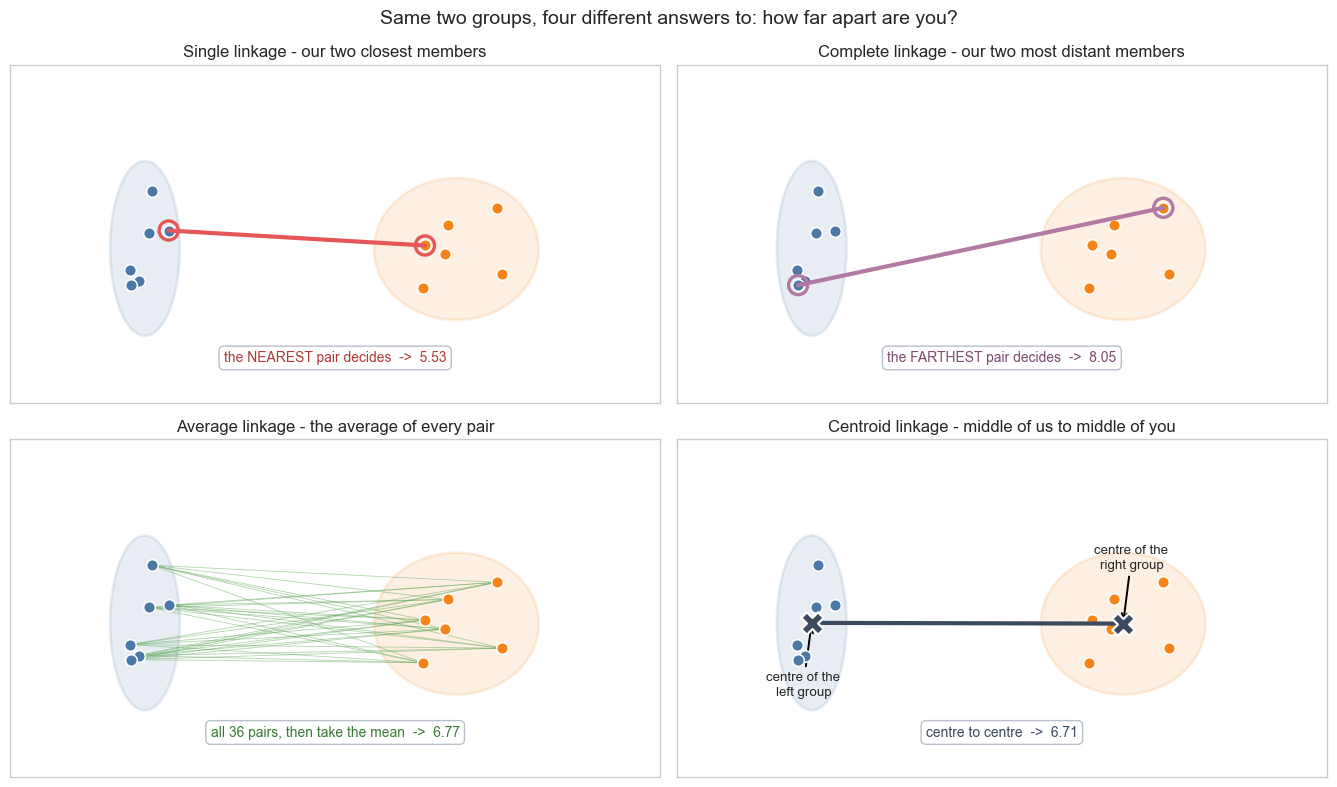

In [7]:
from matplotlib.patches import Ellipse

rng = np.random.default_rng(7)
blob_left = rng.normal([3.0, 5.0], [0.85, 0.9], size=(6, 2))
blob_right = rng.normal([10.5, 5.2], [0.85, 0.9], size=(6, 2))

cross = np.linalg.norm(blob_left[:, None, :] - blob_right[None, :, :], axis=2)
near_i, near_j = np.unravel_index(cross.argmin(), cross.shape)
far_i, far_j = np.unravel_index(cross.argmax(), cross.shape)

def draw_blobs(ax):
    for blob, colour in [(blob_left, "#4C78A8"), (blob_right, "#F58518")]:
        centre, spread = blob.mean(axis=0), blob.std(axis=0)
        ax.add_patch(Ellipse(centre, spread[0] * 5.2, spread[1] * 5.2, facecolor=colour,
                             alpha=.13, edgecolor=colour, linewidth=2))
        ax.scatter(blob[:, 0], blob[:, 1], s=70, color=colour,
                   edgecolor="white", linewidth=1.1, zorder=4)
    ax.set_xlim(0, 14); ax.set_ylim(1.5, 9)
    ax.set_xticks([]); ax.set_yticks([])

note = dict(fontsize=10, ha="center",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#B8C0CC"))

fig, axes = plt.subplots(2, 2, figsize=(13.5, 8))
ax1, ax2, ax3, ax4 = axes.ravel()

# --- Single: the two nearest members decide ---
draw_blobs(ax1)
ax1.plot([blob_left[near_i, 0], blob_right[near_j, 0]],
         [blob_left[near_i, 1], blob_right[near_j, 1]], color="#E45756", linewidth=3, zorder=5)
ax1.scatter([blob_left[near_i, 0], blob_right[near_j, 0]],
            [blob_left[near_i, 1], blob_right[near_j, 1]],
            s=190, facecolor="none", edgecolor="#E45756", linewidth=2.4, zorder=6)
ax1.text(7, 2.4, f"the NEAREST pair decides  ->  {cross.min():.2f}", color="#B03A39", **note)
ax1.set_title("Single linkage - our two closest members", fontsize=12)

# --- Complete: the two farthest members decide ---
draw_blobs(ax2)
ax2.plot([blob_left[far_i, 0], blob_right[far_j, 0]],
         [blob_left[far_i, 1], blob_right[far_j, 1]], color="#B279A2", linewidth=3, zorder=5)
ax2.scatter([blob_left[far_i, 0], blob_right[far_j, 0]],
            [blob_left[far_i, 1], blob_right[far_j, 1]],
            s=190, facecolor="none", edgecolor="#B279A2", linewidth=2.4, zorder=6)
ax2.text(7, 2.4, f"the FARTHEST pair decides  ->  {cross.max():.2f}", color="#7B4B70", **note)
ax2.set_title("Complete linkage - our two most distant members", fontsize=12)

# --- Average: every pair votes ---
draw_blobs(ax3)
for a in blob_left:
    for b in blob_right:
        ax3.plot([a[0], b[0]], [a[1], b[1]], color="#54A24B", linewidth=.6, alpha=.45, zorder=3)
ax3.text(7, 2.4, f"all {cross.size} pairs, then take the mean  ->  {cross.mean():.2f}",
         color="#3B7A34", **note)
ax3.set_title("Average linkage - the average of every pair", fontsize=12)

# --- Centroid: only the two centres matter ---
draw_blobs(ax4)
c_left, c_right = blob_left.mean(axis=0), blob_right.mean(axis=0)
ax4.plot([c_left[0], c_right[0]], [c_left[1], c_right[1]],
         color="#3B4A5F", linewidth=3, zorder=5)
ax4.scatter([c_left[0], c_right[0]], [c_left[1], c_right[1]], marker="X", s=260,
            color="#3B4A5F", edgecolor="white", linewidth=1.6, zorder=6)
ax4.annotate("centre of the\nleft group", xy=tuple(c_left), xytext=(-6, -52),
             textcoords="offset points", fontsize=9.5, ha="center",
             arrowprops=dict(arrowstyle="->", linewidth=1.4))
ax4.annotate("centre of the\nright group", xy=tuple(c_right), xytext=(6, 40),
             textcoords="offset points", fontsize=9.5, ha="center",
             arrowprops=dict(arrowstyle="->", linewidth=1.4))
ax4.text(7, 2.4, f"centre to centre  ->  {np.linalg.norm(c_left - c_right):.2f}",
         color="#3B4A5F", **note)
ax4.set_title("Centroid linkage - middle of us to middle of you", fontsize=12)

fig.suptitle("Same two groups, four different answers to: how far apart are you?", fontsize=14)
fig.tight_layout()
plt.show()

## 4. Build and read the dendrogram

A dendrogram records the complete joining history. Read it from the bottom upward:

- Each label at the bottom is one original point.
- A horizontal connection means two points or groups were joined.
- The vertical height shows how different those groups were when they joined.

A low join means “very similar.” A high join means “quite different.”

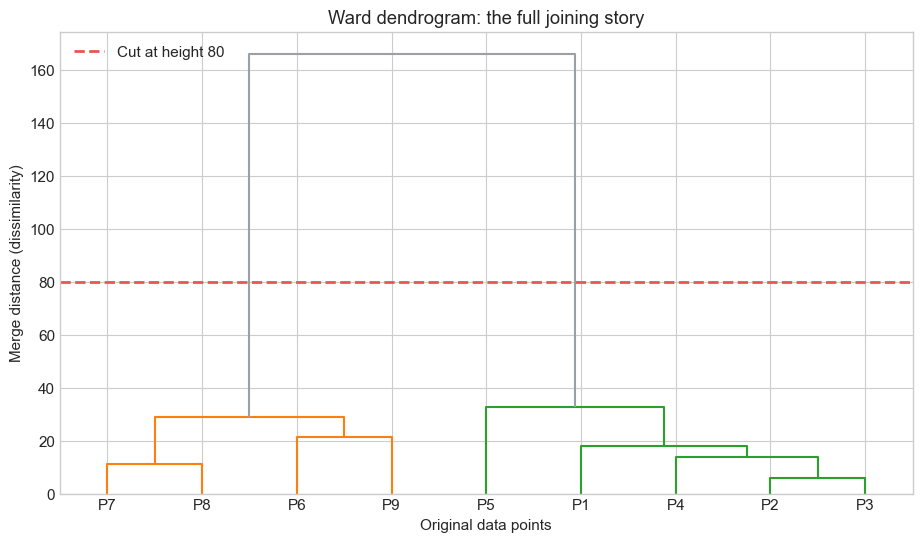

In [8]:
# The linkage matrix stores the complete merge history.
linkage_matrix = linkage(points, method="ward", metric="euclidean")
cut_height = 80

fig, ax = plt.subplots(figsize=(11, 6))
dendrogram(
    linkage_matrix,
    labels=point_names,
    color_threshold=cut_height,
    above_threshold_color="#9AA0A6",
    leaf_font_size=11,
    ax=ax
)
ax.axhline(
    cut_height, color="#E45756", linestyle="--", linewidth=2,
    label=f"Cut at height {cut_height}"
)
ax.set(
    title="Ward dendrogram: the full joining story",
    xlabel="Original data points",
    ylabel="Merge distance (dissimilarity)"
)
ax.legend(loc="upper left")
plt.show()

### Story step 5 — read the diary, part by part

The dendrogram is the diary of every handshake.

Read it from the **bottom upward**, which is the order the story actually happened. The chart below labels each part.

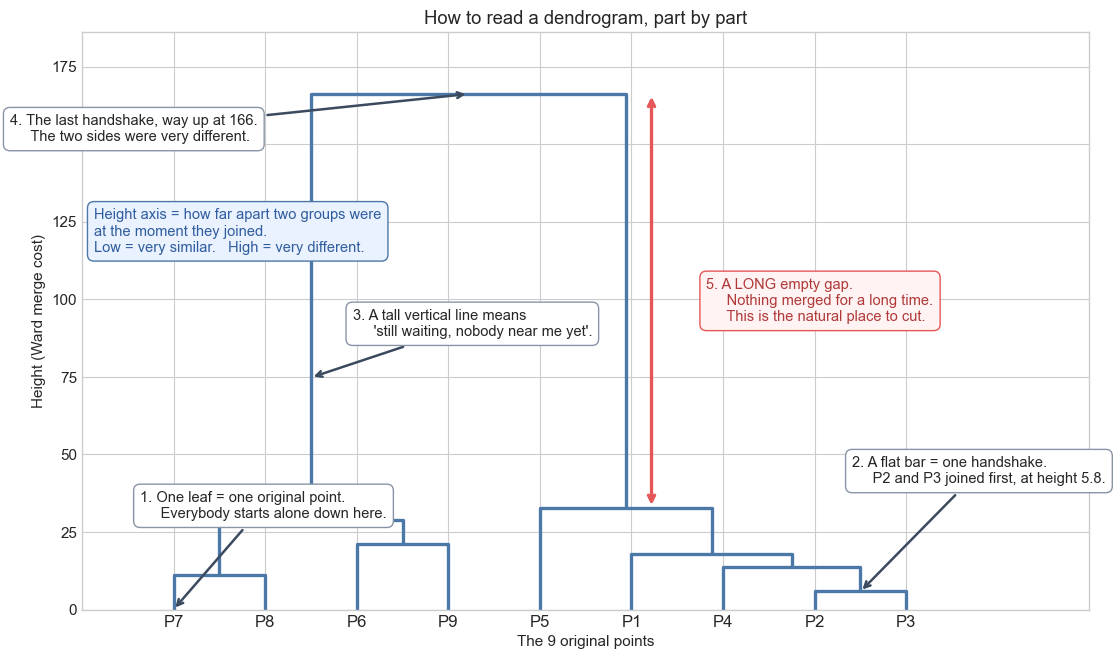

In [9]:
Z = linkage(points, method="ward", metric="euclidean")

fig, ax = plt.subplots(figsize=(13, 7.5))
tree = dendrogram(Z, labels=point_names, ax=ax, color_threshold=0,
                  above_threshold_color="#4C78A8", leaf_font_size=12)
for coll in ax.collections:
    coll.set_linewidth(2.4)

bars = sorted(zip(tree["dcoord"], tree["icoord"]), key=lambda t: max(t[0]))
def bar_top(bar):
    dcoord, icoord = bar
    return float(np.mean(icoord[1:3])), float(max(dcoord))

lowest_x, lowest_y = bar_top(bars[0])
second_x, second_y = bar_top(bars[-2])
top_x, top_y = bar_top(bars[-1])

pin = dict(fontsize=10.5, arrowprops=dict(arrowstyle="->", linewidth=1.8, color="#3B4A5F"),
           bbox=dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor="#8995A7"))

ax.annotate("1. One leaf = one original point.\n     Everybody starts alone down here.",
            xy=(tree["icoord"][0][0], 0), xytext=(-24, 66), textcoords="offset points", **pin)
ax.annotate(f"2. A flat bar = one handshake.\n     P2 and P3 joined first, at height {lowest_y:.1f}.",
            xy=(lowest_x, lowest_y), xytext=(-6, 78), textcoords="offset points", **pin)
ax.annotate("3. A tall vertical line means\n     'still waiting, nobody near me yet'.",
            xy=(tree["icoord"][-1][0], top_y * 0.45), xytext=(30, 30),
            textcoords="offset points", **pin)
ax.annotate(f"4. The last handshake, way up at {top_y:.0f}.\n     The two sides were very different.",
            xy=(top_x, top_y), xytext=(-330, -34), textcoords="offset points", **pin)

ax.annotate("", xy=(top_x + 20, top_y), xytext=(top_x + 20, second_y),
            arrowprops=dict(arrowstyle="<->", linewidth=2.4, color="#E45756"))
ax.text(top_x + 26, (top_y + second_y) / 2,
        "5. A LONG empty gap.\n     Nothing merged for a long time.\n"
        "     This is the natural place to cut.",
        fontsize=10.5, color="#B03A39", va="center",
        bbox=dict(boxstyle="round,pad=0.45", facecolor="#FFF3F3", edgecolor="#E45756"))

ax.annotate("Height axis = how far apart two groups were\nat the moment they joined.\n"
            "Low = very similar.   High = very different.",
            xy=(0.012, 0.62), xycoords="axes fraction", fontsize=10.5, color="#2F5D9E",
            rotation=0, bbox=dict(boxstyle="round,pad=0.45", facecolor="#EAF2FF",
                                  edgecolor="#4C78A8"))

ax.set(title="How to read a dendrogram, part by part",
       xlabel="The 9 original points", ylabel="Height (Ward merge cost)")
ax.set_xlim(-5, 105)
ax.set_ylim(0, top_y * 1.12)
plt.show()

### Turning the tree into clusters

Imagine cutting the dendrogram along the red dashed line. Count the separate colored branches that the line passes through: there are **two**, so this cut gives two clusters.

The large empty vertical gap before the final merge is important. It tells us that the last two groups are much more different from each other than the points inside either group. This makes two clusters a sensible choice for this small dataset.

> The left-to-right order of labels is arranged to display the tree clearly. It is not the original row order and it does not show the value of Feature 1.

### Story step 6 — stop the story early

The full story always ends with one group. That alone is not useful.

So we stop the story early. Draw a horizontal line across the diary and count how many branches that line cuts. **That count is your number of clusters.**

Cut inside the long empty gap. Nothing merged there, so cutting there does not break apart anything that belonged together.

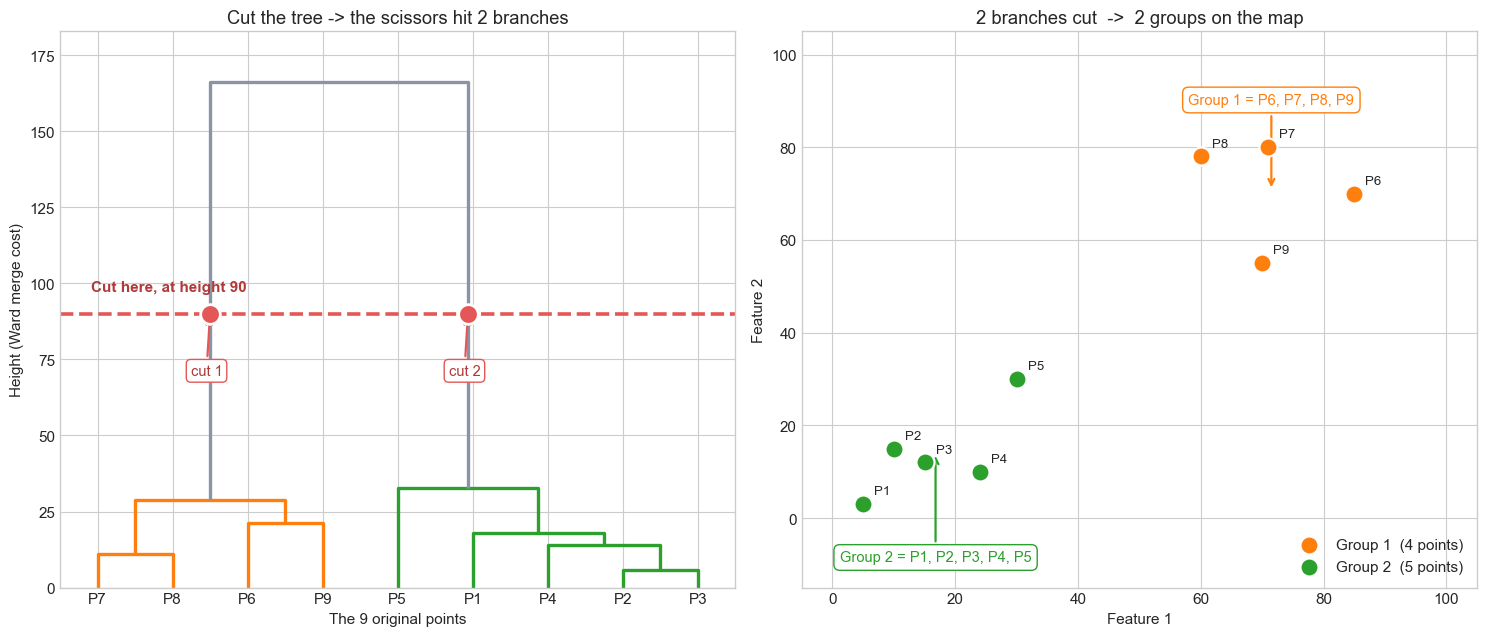

cut height 90  ->  2 clusters
  group 1: P6, P7, P8, P9
  group 2: P1, P2, P3, P4, P5


In [10]:
from scipy.cluster.hierarchy import fcluster

Z = linkage(points, method="ward", metric="euclidean")
cut_height = 90                      # anywhere inside the long empty gap works

fig, (ax_tree, ax_map) = plt.subplots(1, 2, figsize=(15, 6.5))

# ---------- LEFT: cut the diary ----------
tree = dendrogram(Z, labels=point_names, ax=ax_tree, color_threshold=cut_height,
                  above_threshold_color="#8995A7", leaf_font_size=11)
for coll in ax_tree.collections:
    coll.set_linewidth(2.4)
ax_tree.axhline(cut_height, color="#E45756", linestyle="--", linewidth=2.6)

crossings = []                       # where the scissors actually cut a branch
for xs, ys in zip(tree["icoord"], tree["dcoord"]):
    for x, low, high in [(xs[0], ys[0], ys[1]), (xs[3], ys[3], ys[2])]:
        if low < cut_height < high:
            crossings.append(x)
for x in crossings:
    ax_tree.scatter(x, cut_height, s=200, color="#E45756", zorder=8,
                    edgecolor="white", linewidth=2)

ax_tree.annotate(f"Cut here, at height {cut_height}",
                 xy=(3, cut_height), xytext=(6, 16), textcoords="offset points",
                 color="#B03A39", fontsize=11, fontweight="bold")
for n, x in enumerate(sorted(crossings), start=1):
    ax_tree.annotate(f"cut {n}", xy=(x, cut_height), xytext=(-14, -44),
                     textcoords="offset points", fontsize=10.5, color="#B03A39",
                     arrowprops=dict(arrowstyle="->", linewidth=1.6, color="#E45756"),
                     bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#E45756"))
ax_tree.set(title=f"Cut the tree -> the scissors hit {len(crossings)} branches",
            xlabel="The 9 original points", ylabel="Height (Ward merge cost)")
ax_tree.set_ylim(0, max(max(d) for d in tree["dcoord"]) * 1.1)

# ---------- RIGHT: the groups that fall out ----------
labels = fcluster(Z, t=cut_height, criterion="distance")

# Borrow the exact branch colour the dendrogram used, so both panels agree.
leaf_colour = dict(zip(tree["ivl"], tree["leaves_color_list"]))
colours = {label: leaf_colour[name]
           for name, label in zip(point_names, labels)}

for label in np.unique(labels):
    block = points[labels == label]
    ax_map.scatter(block[:, 0], block[:, 1], s=170, color=colours[label],
                   edgecolor="white", linewidth=1.6, zorder=4,
                   label=f"Group {label}  ({(labels == label).sum()} points)")
    centre = block.mean(axis=0)
    ax_map.annotate(f"Group {label} = " + ", ".join(np.array(point_names)[labels == label]),
                    xy=tuple(centre), xytext=(0, 62 if label == 1 else -78),
                    textcoords="offset points", ha="center", fontsize=10.5,
                    color=colours[label],
                    arrowprops=dict(arrowstyle="->", linewidth=1.6, color=colours[label]),
                    bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                              edgecolor=colours[label]))

for name, (x, y) in zip(point_names, points):
    ax_map.annotate(name, (x, y), xytext=(8, 7), textcoords="offset points", fontsize=9.5)

ax_map.set(title=f"{len(crossings)} branches cut  ->  {len(crossings)} groups on the map",
           xlabel="Feature 1", ylabel="Feature 2")
ax_map.set_xlim(-5, 105); ax_map.set_ylim(-15, 105)
ax_map.legend(loc="lower right")

fig.tight_layout()
plt.show()

print(f"cut height {cut_height}  ->  {len(np.unique(labels))} clusters")
for label in np.unique(labels):
    print(f"  group {label}: {', '.join(np.array(point_names)[labels == label])}")

## 5. Fit the model and display the final clusters

The dendrogram helped us choose two groups. Now `AgglomerativeClustering` assigns a cluster number to every point.

Cluster numbers are only names. “Cluster 1” is not better or more important than “Cluster 2.”

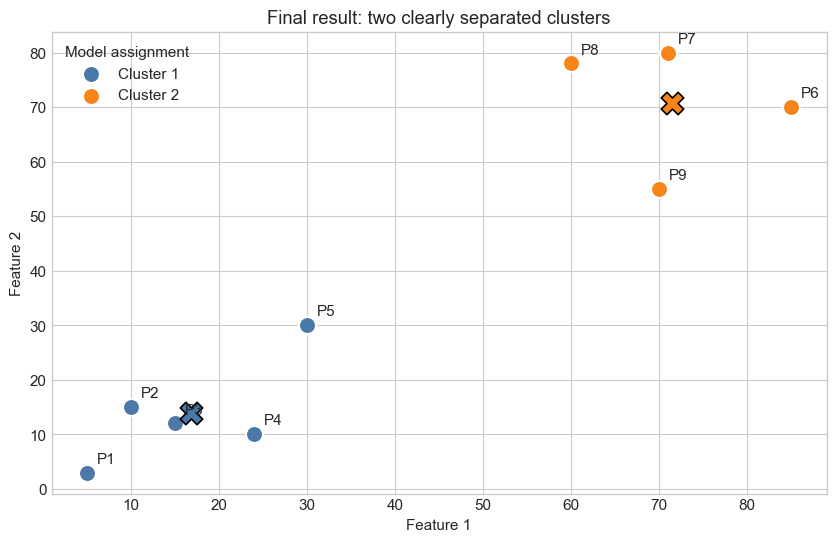

Cluster 1: P1, P2, P3, P4, P5
Cluster 2: P6, P7, P8, P9


In [11]:
model = AgglomerativeClustering(n_clusters=2, linkage="ward")
cluster_ids = model.fit_predict(points)

colors = ["#4C78A8", "#F58518"]
fig, ax = plt.subplots(figsize=(10, 6))

for cluster_id in np.unique(cluster_ids):
    mask = cluster_ids == cluster_id
    cluster_points = points[mask]
    center = cluster_points.mean(axis=0)

    ax.scatter(
        cluster_points[:, 0], cluster_points[:, 1],
        s=150, color=colors[cluster_id], edgecolor="white", linewidth=1.5,
        label=f"Cluster {cluster_id + 1}"
    )
    ax.scatter(
        center[0], center[1], marker="X", s=260,
        color=colors[cluster_id], edgecolor="black", linewidth=1.2
    )

for name, (x, y) in zip(point_names, points):
    ax.annotate(name, (x, y), xytext=(7, 7), textcoords="offset points")

ax.set(
    title="Final result: two clearly separated clusters",
    xlabel="Feature 1", ylabel="Feature 2"
)
ax.legend(title="Model assignment")
plt.show()

for cluster_id in np.unique(cluster_ids):
    members = [name for name, label in zip(point_names, cluster_ids) if label == cluster_id]
    print(f"Cluster {cluster_id + 1}: {', '.join(members)}")

### Interpretation

The model places the five lower-left points together and the four upper-right points together. This matches both the original scatter plot and the two main branches in the dendrogram.

The **X** markers show the average position of each cluster. They are included only as a visual summary; hierarchical clustering does not work by repeatedly moving these centers like K-means does.

## 6. Optional visual: compare linkage methods

The same points can produce different trees because each linkage method defines “closest groups” differently. Focus on the overall tree shape rather than memorizing every branch.

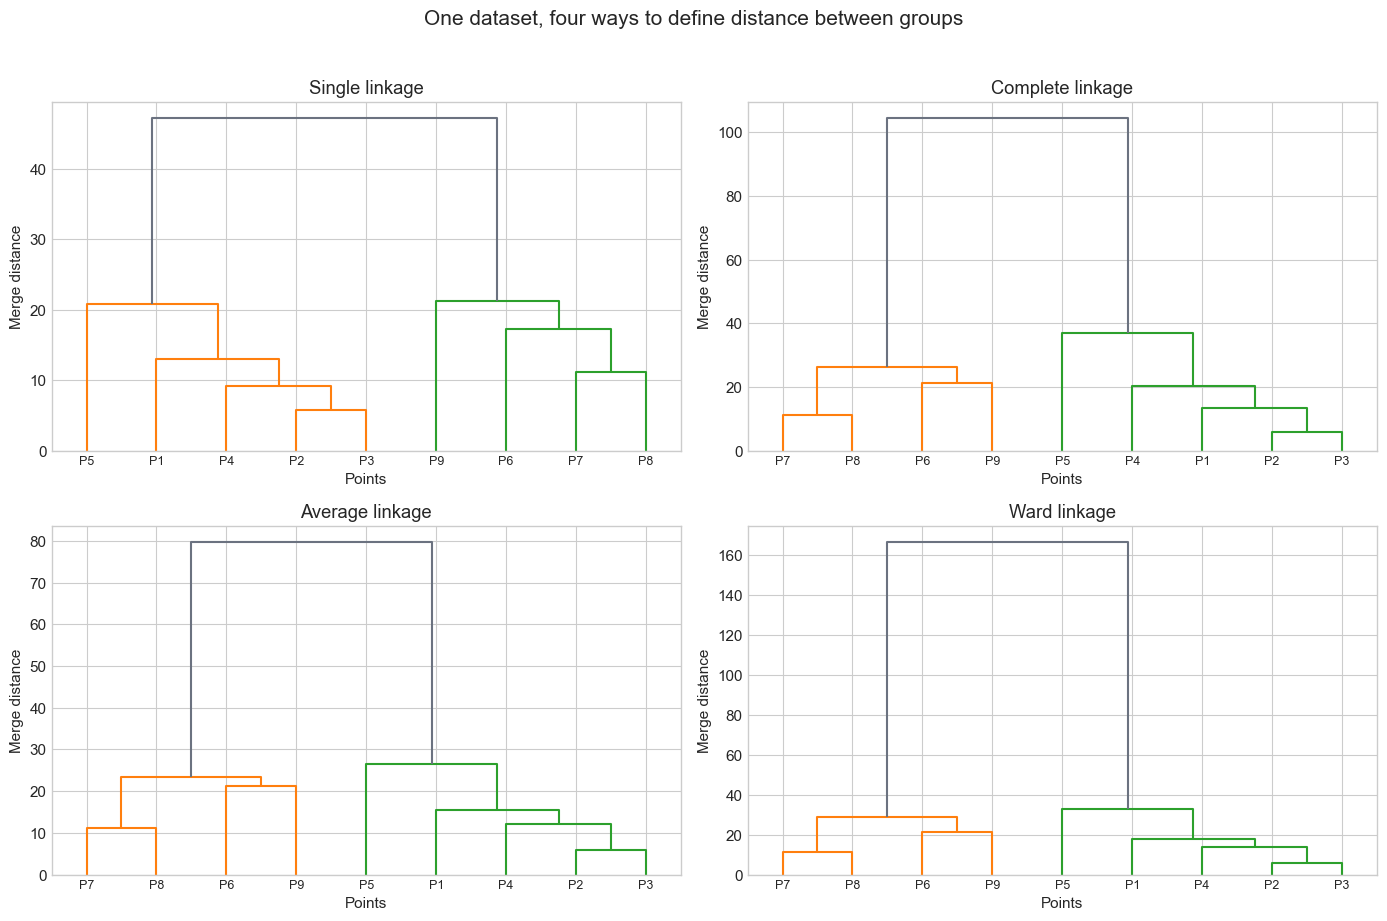

In [12]:
methods = ["single", "complete", "average", "ward"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, method in zip(axes.ravel(), methods):
    method_matrix = linkage(points, method=method, metric="euclidean")
    dendrogram(
        method_matrix, labels=point_names, leaf_font_size=9,
        above_threshold_color="#6B7280", ax=ax
    )
    ax.set_title(f"{method.title()} linkage")
    ax.set_xlabel("Points")
    ax.set_ylabel("Merge distance")

fig.suptitle("One dataset, four ways to define distance between groups", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

## 7. Practical notes for real datasets

Keep these three ideas in mind:

1. **Scale numeric features first.** A feature measured in thousands can dominate one measured from 0 to 10. `StandardScaler` is a common solution.
2. **Outliers can change the tree.** Plot the data and inspect unusual points before interpreting clusters.
3. **Large datasets create crowded dendrograms.** Hierarchical clustering is easiest to interpret on small or medium datasets.

Hierarchical clustering is especially useful when you want to explore nested groups and see the full grouping history.

## Recap

- Hierarchical clustering begins with separate points and joins nearby groups.
- Linkage tells the algorithm how to compare two groups.
- A dendrogram shows which groups joined and the distance at which they joined.
- A horizontal cut through the dendrogram gives the final clusters.
- For this dataset, the large jump before the last merge supports **two clusters**.

### Quick check

Try changing `n_clusters=2` to `n_clusters=3` in the model cell. Which existing group gets divided? Then move the red dendrogram cut lower and check whether the tree tells the same story.

## The whole story in six lines

1. Every point starts alone. Nine points means nine groups.
2. Measure distance, so each group knows who is nearest.
3. The two closest groups shake hands and become one.
4. **Linkage** decides what "closest" means once a group has many members.
5. Repeat until one group is left. The **dendrogram** records every handshake and the height it happened at.
6. Cut the dendrogram inside a big empty gap. The branches you cut are your clusters.

> If you remember only one thing: **hierarchical clustering does not choose the number of clusters for you. It writes the full history, and you decide where to cut it.**